## question-1

In [35]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
import numpy as np

In [36]:
data = np.array([1,4,8])
data_scaled = (data - np.min(data)) / (np.max(data) - np.min(data)) * 2 *np.pi
print(f"data; {data}"
      f"\ndata_scaled: {data_scaled}")

data; [1 4 8]
data_scaled: [0.         2.6927937  6.28318531]


In [37]:
feat_map = ZZFeatureMap(feature_dimension=3, reps=1, entanglement='linear')
qc1 = feat_map.assign_parameters(data_scaled)
qc1 = qc1.decompose()
print(f"Circuit depth: {qc1.depth()}")


Circuit depth: 8


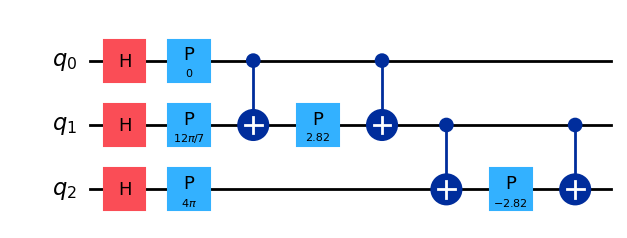

In [38]:
qc1.draw('mpl')

In [41]:
qc1_phase = QuantumCircuit(3)
qc1_phase.rz(data_scaled[0], 0)
qc1_phase.rz(data_scaled[1], 1)
qc1_phase.rz(data_scaled[2], 2)


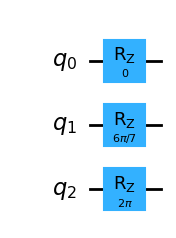

In [42]:
qc1_phase.draw('mpl')

## question 2

Parametric Circuit (with !, @, $):


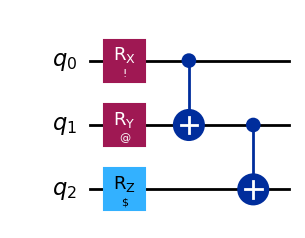

In [33]:

import matplotlib.pyplot as plt

from qiskit.circuit import Parameter

# alpha = !, beta = @, gamma = $
alpha = Parameter('!')
beta  = Parameter('@')
gamma = Parameter('$')

qc2_param = QuantumCircuit(3)


qc2_param.rx(alpha, 0)
qc2_param.ry(beta,  1)
qc2_param.rz(gamma, 2)


qc2_param.cx(0, 1)
qc2_param.cx(1, 2)

print("Parametric Circuit (with !, @, $):")
display(qc2_param.draw('mpl'))

Circuit with !=1, @=4, $=8:


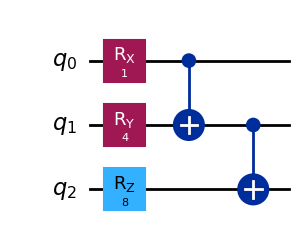

In [34]:
param_values = {alpha: 1, beta: 4, gamma: 8}

qc_bound = qc2_param.assign_parameters(param_values)

print("Circuit with !=1, @=4, $=8:")
display(qc_bound.draw('mpl'))



## question 3


In [35]:
pip install qiskit_algorithms

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
pip install qiskit-machine-learning


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
pip install pennylane

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt


In [ ]:

# # 1. Loading and Preprocess Data

# def load_data(file='leukemia_small.csv'):
    
#     data = pd.read_csv(file)

#     # First row contains labels (ALL or AML)
#     labels = data.iloc[0].values
#     # y = np.array([0 if l == 'ALL' else 1 for l in labels])  # 0=ALL, 1=AML
#     y = np.array([0 if label.strip().upper() == 'ALL' else 1 for label in labels])

#     # Remaining rows are features (transpose to samples x features)
#     X = data.iloc[1:].values.T.astype(float)

#     print(f"Data loaded: X={X.shape}, y={y.shape}")
#     print(f"ALL: {np.sum(y==0)}, AML: {np.sum(y==1)}")
#     return X, y


def load_data(file='leukemia_small.csv'):
    
    df = pd.read_csv(file, header=None)

    # If labels are in first row (strings)
    if df.iloc[0].dtype == 'object' or isinstance(df.iloc[0, 0], str):
        labels = df.iloc[0].astype(str).str.strip().str.upper().values
        X = df.iloc[1:].values.T.astype(float)

    # If labels are in last row (strings)
    elif df.iloc[-1].dtype == 'object' or isinstance(df.iloc[-1, 0], str):
        labels = df.iloc[-1].astype(str).str.strip().str.upper().values
        X = df.iloc[:-1].values.T.astype(float)

    # If labels are in first column instead of row
    elif df.iloc[:, 0].dtype == 'object' or isinstance(df.iloc[0, 0], str):
        labels = df.iloc[:, 0].astype(str).str.strip().str.upper().values
        X = df.iloc[:, 1:].values.astype(float)

    else:
        raise ValueError("Could not locate label row/column (ALL/AML) in the CSV file.")

    y = np.array([0 if l == 'ALL' else 1 for l in labels])

    print(f"Data loaded: X={X.shape}, y={y.shape}")
    print(f"Class distribution: ALL={np.sum(y==0)}, AML={np.sum(y==1)}")

    return X, y


In [ ]:

# 2. Feature Selection and Scaling


def select_top_features(X, y, k=20):
    
    selector = SelectKBest(f_classif, k=k)
    X_new = selector.fit_transform(X, y)
    print(f"Selected {k} best features.")
    return X_new

def preprocess(X, y, test_ratio=0.3):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Clip to [-pi, pi] for quantum rotation angles
    X_train = np.clip(X_train, -3, 3) * (np.pi / 3)
    X_test = np.clip(X_test, -3, 3) * (np.pi / 3)

    return X_train, X_test, y_train, y_test


In [ ]:

# 3. Define Quantum Circuits


n_qubits = 10
n_layers = 3
n_features = 20

dev = qml.device("default.qubit", wires=n_qubits)


In [49]:

def S_x(x):
    
    # First 10 features → RY rotations
    for a in range(min(n_qubits, len(x))):
        qml.RY(x[a], wires=a)

    # Entangle all qubits
    for a in range(n_qubits - 1):
        qml.CNOT(wires=[a, a + 1])

    # Next 10 features → RZ rotations
    for a in range(min(n_qubits, len(x) - n_qubits)):
        qml.RZ(x[n_qubits + a], wires=a)

    # Extra CZ entanglement for even pairs
    for a in range(0, n_qubits - 1, 2):
        qml.CZ(wires=[a, a + 1])

def W_theta(params):
    
    for layer in range(n_layers):
        # Apply RX, RY, RZ to each qubit
        for q in range(n_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
            qml.RZ(params[layer, q, 2], wires=q)

        # CNOT entanglement (ring connection)
        for q in range(n_qubits):
            qml.CNOT(wires=[q, (q + 1) % n_qubits])

        # Extra CZ for variety
        if layer < n_layers - 1:
            for q in range(0, n_qubits, 2):
                qml.CZ(wires=[q, (q + 2) % n_qubits])

@qml.qnode(dev, interface="autograd")
def quantum_model(x, params):
    S_x(x)
    W_theta(params)
    return qml.expval(qml.PauliZ(0))

def predict(x, params):
    """Map circuit output (-1,1) → (0,1)."""
    val = quantum_model(x, params)
    return (1 - val) / 2


In [ ]:

# 4. Loss, Accuracy, and Training


def loss_fn(params, X, y):
    preds = pnp.array([predict(x, params) for x in X])
    preds = pnp.clip(preds, 1e-10, 1 - 1e-10)
    return -pnp.mean(y * pnp.log(preds) + (1 - y) * pnp.log(1 - preds))

def acc_fn(params, X, y):
    preds = np.array([predict(x, params) for x in X])
    return np.mean((preds >= 0.5).astype(int) == y)

def train(X_train, y_train, X_test, y_test, epochs=50, lr=0.01):
    np.random.seed(42)
    params = pnp.array(np.random.uniform(0, 2 * np.pi, (n_layers, n_qubits, 3)), requires_grad=True)
    y_train_p = pnp.array(y_train)
    opt = qml.AdamOptimizer(stepsize=lr)

    print("\nTraining QVC...")
    print(f"{'Epoch':<6} {'Loss':<10} {'Train Acc':<10} {'Test Acc':<10}")
    print("-" * 40)

    losses, train_accs, test_accs = [], [], []

    for ep in range(epochs):
        params, cost = opt.step_and_cost(lambda p: loss_fn(p, X_train, y_train_p), params)
        losses.append(cost)

        if (ep + 1) % 5 == 0 or ep == 0:
            tr_acc = acc_fn(params, X_train, y_train)
            te_acc = acc_fn(params, X_test, y_test)
            train_accs.append(tr_acc)
            test_accs.append(te_acc)
            print(f"{ep+1:<6} {cost:<10.4f} {tr_acc:<10.2%} {te_acc:<10.2%}")

    return params, losses, train_accs, test_accs


In [ ]:


# 5. Plot and Results

def plot_training(losses, train_accs, test_accs):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(losses, lw=2)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    # Accuracy
    plt.subplot(1, 2, 2)
    epochs = list(range(1, len(train_accs) * 5 + 1, 5))
    plt.plot(epochs, train_accs, "o-", label="Train Acc")
    plt.plot(epochs, test_accs, "s-", label="Test Acc")
    plt.axhline(y=0.85, color="r", ls="--", label="85% Target")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


Quantum Variational Classifier (Simplified)
Data loaded: X=(72, 3571), y=(72,)
Class distribution: ALL=47, AML=25
Selected 20 best features.

Train: (50, 20), Test: (22, 20)

Circuit Info:
Qubits: 10, Layers: 3, Params: 90

Training QVC...
Epoch  Loss       Train Acc  Test Acc  
----------------------------------------
1      0.7108     30.00%     22.73%    
5      0.7002     48.00%     31.82%    
10     0.6891     52.00%     40.91%    
15     0.6778     68.00%     63.64%    
20     0.6654     78.00%     68.18%    
25     0.6530     82.00%     72.73%    
30     0.6417     84.00%     72.73%    
35     0.6318     84.00%     77.27%    
40     0.6227     84.00%     81.82%    
45     0.6128     86.00%     81.82%    
50     0.6008     86.00%     72.73%    

Final Accuracy:
Train: 86.00%, Test: 72.73%
✗


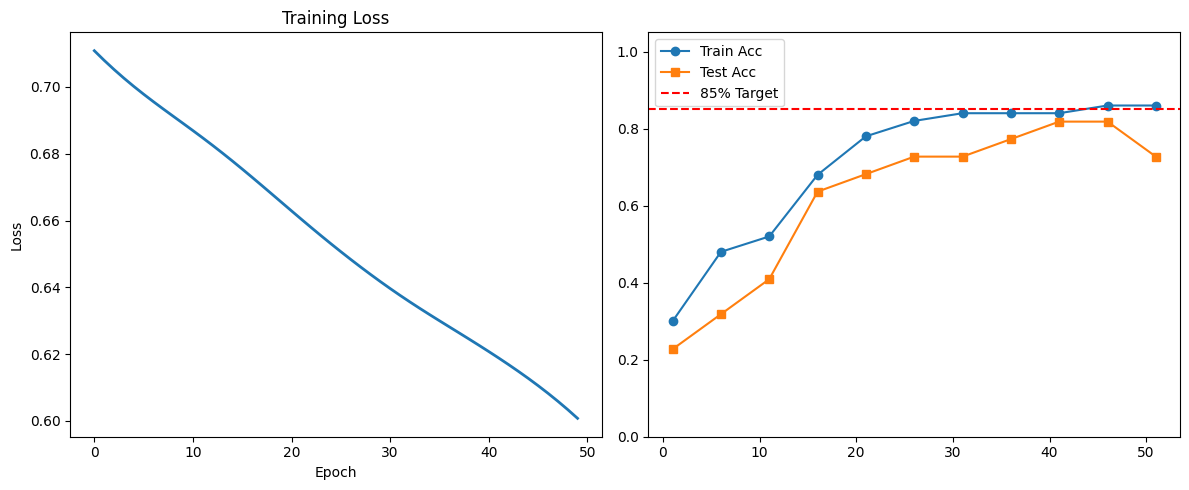

In [ ]:
####
### 1st try with 50 epochs, lr = 0.01
####

# 6. Main Execution


if __name__ == "__main__":
    
    print("Quantum Variational Classifier (Simplified)")
    
    
    # Load & preprocess
    X, y = load_data()
    X = select_top_features(X, y, k=n_features)
    X_train, X_test, y_train, y_test = preprocess(X, y)

    print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

    print("\nCircuit Info:")
    print(f"Qubits: {n_qubits}, Layers: {n_layers}, Params: {n_layers * n_qubits * 3}")

    # Train model
    params, losses, tr_acc, te_acc = train(X_train, y_train, X_test, y_test, epochs=50, lr=0.01)

    # Final results
    final_train = acc_fn(params, X_train, y_train)
    final_test = acc_fn(params, X_test, y_test)
    print("\nFinal Accuracy:")
    print(f"Train: {final_train:.2%}, Test: {final_test:.2%}")
    print("Target Achieved:" if final_train > 0.85 and final_test > 0.85 else "✗")

    # Plot
    plot_training(losses, tr_acc, te_acc)


Quantum Variational Classifier (Simplified)
Data loaded: X=(72, 3571), y=(72,)
Class distribution: ALL=47, AML=25
Selected 20 best features.

Train: (50, 20), Test: (22, 20)

Circuit Info:
Qubits: 10, Layers: 4, Params: 120

Training QVC...
Epoch  Loss       Train Acc  Test Acc  
----------------------------------------
1      0.7013     40.00%     40.91%    
5      0.6827     66.00%     50.00%    
10     0.6651     78.00%     68.18%    
15     0.6520     90.00%     72.73%    
20     0.6402     94.00%     72.73%    
25     0.6301     96.00%     72.73%    
30     0.6229     96.00%     68.18%    
35     0.6182     96.00%     81.82%    
40     0.6147     96.00%     81.82%    
45     0.6115     98.00%     81.82%    
50     0.6086     98.00%     81.82%    
55     0.6059     98.00%     81.82%    
60     0.6031     98.00%     81.82%    
65     0.6001     98.00%     86.36%    
70     0.5965     98.00%     86.36%    
75     0.5920     94.00%     86.36%    
80     0.5858     94.00%     86.36%   

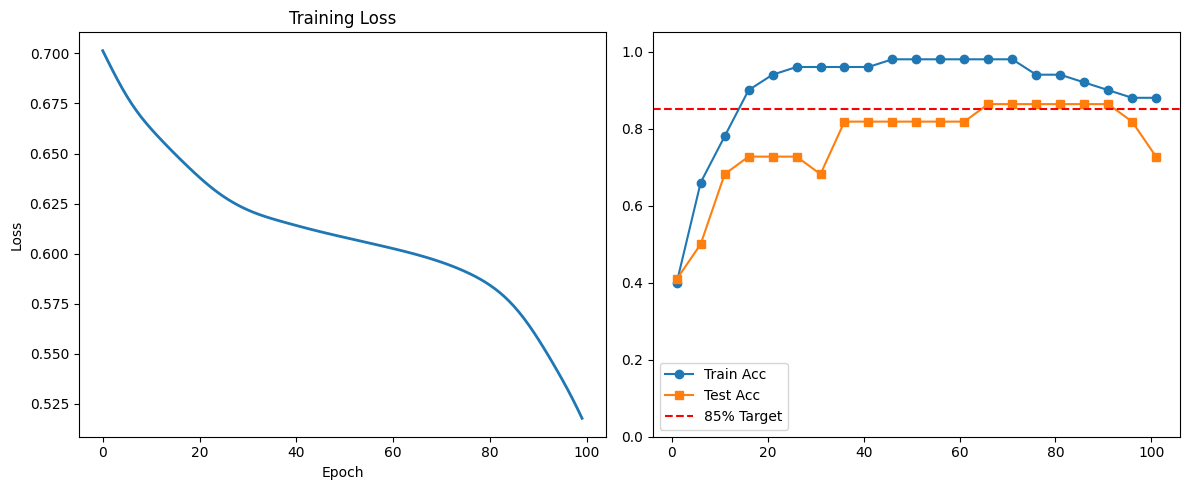

In [ ]:
###
# 2nd try 100 epochs, lr = 0.01, layers = 4
###
# 6. Main Execution


if __name__ == "__main__":
    
    print("Quantum Variational Classifier (Simplified)")
    
    
    # Load & preprocess
    X, y = load_data()
    X = select_top_features(X, y, k=n_features)
    X_train, X_test, y_train, y_test = preprocess(X, y)

    print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

    print("\nCircuit Info:")
    print(f"Qubits: {n_qubits}, Layers: {n_layers}, Params: {n_layers * n_qubits * 3}")

    # Train model
    params, losses, tr_acc, te_acc = train(X_train, y_train, X_test, y_test, epochs=100, lr=0.01)

    # Final results
    final_train = acc_fn(params, X_train, y_train)
    final_test = acc_fn(params, X_test, y_test)
    print("\nFinal Accuracy:")
    print(f"Train: {final_train:.2%}, Test: {final_test:.2%}")
    print("Target Achieved: yesss!!" if final_train > 0.85 and final_test > 0.85 else "Target not achieved")

    # Plot
    plot_training(losses, tr_acc, te_acc)


In [53]:
n_qubits = 10
n_layers = 4
n_features = 20

dev = qml.device("default.qubit", wires=n_qubits)



## submission 70 epochs, lr = 0.01, layers = 4

Quantum Variational Classifier (Simplified)
Data loaded: X=(72, 3571), y=(72,)
Class distribution: ALL=47, AML=25
Selected 20 best features.

Train: (50, 20), Test: (22, 20)

Circuit Info:
Qubits: 10, Layers: 4, Params: 120

Training QVC...
Epoch  Loss       Train Acc  Test Acc  
----------------------------------------
1      0.7013     40.00%     40.91%    
5      0.6827     66.00%     50.00%    
10     0.6651     78.00%     68.18%    
15     0.6520     90.00%     72.73%    
20     0.6402     94.00%     72.73%    
25     0.6301     96.00%     72.73%    
30     0.6229     96.00%     68.18%    
35     0.6182     96.00%     81.82%    
40     0.6147     96.00%     81.82%    
45     0.6115     98.00%     81.82%    
50     0.6086     98.00%     81.82%    
55     0.6059     98.00%     81.82%    
60     0.6031     98.00%     81.82%    
65     0.6001     98.00%     86.36%    
70     0.5965     98.00%     86.36%    

Final Accuracy:
Train: 98.00%, Test: 86.36%
Target Achieved: yesss!!


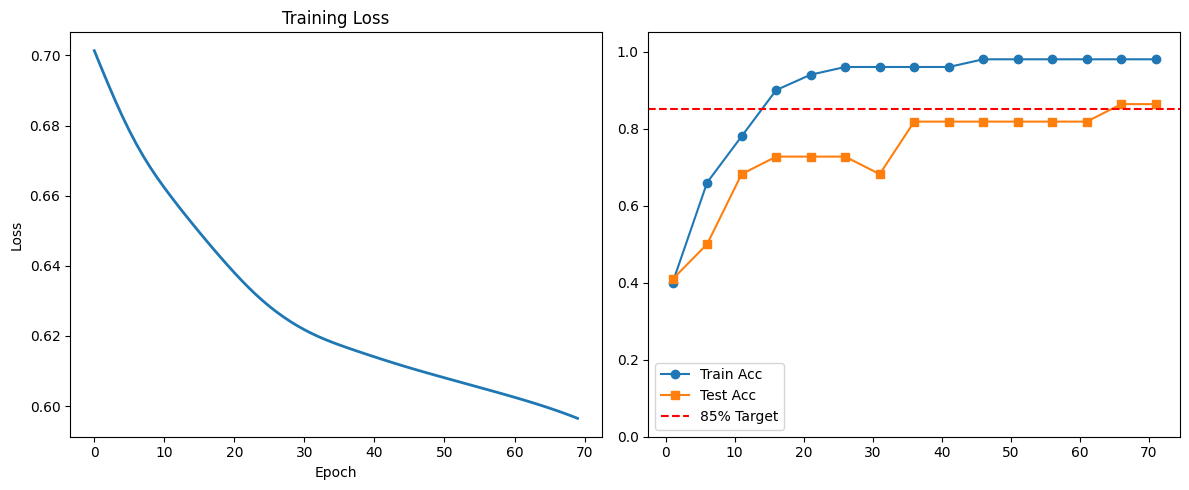

In [ ]:

# 6. Main Execution


if __name__ == "__main__":
    
    print("Quantum Variational Classifier (Simplified)")
    
    
    # Load & preprocess
    X, y = load_data()
    X = select_top_features(X, y, k=n_features)
    X_train, X_test, y_train, y_test = preprocess(X, y)

    print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

    print("\nCircuit Info:")
    print(f"Qubits: {n_qubits}, Layers: {n_layers}, Params: {n_layers * n_qubits * 3}")

    # Train model
    params, losses, tr_acc, te_acc = train(X_train, y_train, X_test, y_test, epochs=70, lr=0.01)

    # Final results
    final_train = acc_fn(params, X_train, y_train)
    final_test = acc_fn(params, X_test, y_test)
    print("\nFinal Accuracy:")
    print(f"Train: {final_train:.2%}, Test: {final_test:.2%}")
    print("Target Achieved: yesss!!" if final_train > 0.85 and final_test > 0.85 else "Target not achieved")

    # Plot
    plot_training(losses, tr_acc, te_acc)


## question 4

In [14]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [ ]:


# Data Loading and Preprocessing


def load_data(filepath='leukemia_small.csv'):
    
    df = pd.read_csv(filepath, header=None)
    labels = df.iloc[0].values
    y = np.array([0 if label == 'ALL' else 1 for label in labels])
    X = df.iloc[1:].values.T.astype(float)

    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    print(f"Class distribution: ALL={np.sum(y==0)}, AML={np.sum(y==1)}")
    return X, y


def select_features_robust(X, y, n_features=20):
    
    
    print("FEATURE SELECTION (Cross-validated)")
    
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    feature_scores = np.zeros(X.shape[1])

    for train_idx, _ in skf.split(X, y):
        selector = SelectKBest(f_classif, k=n_features)
        selector.fit(X[train_idx], y[train_idx])
        feature_scores += selector.scores_ / n_splits

    top_features = np.argsort(feature_scores)[-n_features:]
    X_selected = X[:, top_features]

    print(f"Selected top {n_features} features (stable across folds).")
    return X_selected, top_features


def preprocess_data_with_validation(X, y, test_size=0.25, val_size=0.15, random_state=42):
    
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
    )

    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_val_std = scaler.transform(X_val)
    X_test_std = scaler.transform(X_test)

    min_max_scaler = MinMaxScaler(feature_range=(0, np.pi * 0.75))
    X_train_scaled = min_max_scaler.fit_transform(X_train_std)
    X_val_scaled = min_max_scaler.transform(X_val_std)
    X_test_scaled = min_max_scaler.transform(X_test_std)

    print("DATA SPLIT SUMMARY")

    print(f"\n Train: {X_train_scaled.shape[0]} samples")
    print(f"\n Validation: {X_val_scaled.shape[0]} samples")
    print(f"\n Test: {X_test_scaled.shape[0]} samples")

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test



In [22]:
# Quantum Kernel Setup


n_qubits = 8
n_features = 12
dev = qml.device('default.qubit', wires=n_qubits)

def feature_map_moderate(x):
    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for i in range(n_qubits):
        feature_idx = i * 2 % n_features
        qml.RY(x[feature_idx] * 0.7, wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    for i in range(n_qubits):
        feature_idx = (i * 2 + 1) % n_features
        qml.RZ(x[feature_idx] * 0.5, wires=i)


def create_kernel_circuit(feature_map_func):
    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        feature_map_func(x1)
        qml.adjoint(feature_map_func)(x2)
        return qml.probs(wires=range(n_qubits))
    return kernel_circuit


def compute_kernel_matrix(X1, X2, kernel_circuit, desc="Computing kernel"):
    
    n1, n2 = len(X1), len(X2)
    K = np.zeros((n1, n2))
    with tqdm(total=n1*n2, desc=desc) as pbar:
        for i in range(n1):
            for j in range(n2):
                probs = kernel_circuit(X1[i], X2[j])
                K[i, j] = probs[0]
                pbar.update(1)
    if n1 == n2:
        K += np.eye(n1) * 1e-8
    return K


In [23]:

# QSVM Training and Evaluation


def train_qsvm(X_train, y_train, X_val, y_val, X_test, y_test):
    
    print("TRAINING QSVM")
    

    kernel_circuit = create_kernel_circuit(feature_map_moderate)

    K_train = compute_kernel_matrix(X_train, X_train, kernel_circuit, "Train kernel")
    K_val = compute_kernel_matrix(X_val, X_train, kernel_circuit, "Validation kernel")
    K_test = compute_kernel_matrix(X_test, X_train, kernel_circuit, "Test kernel")

    # Hyperparameter tuning (conservative range)
    C_values = [0.05, 0.1, 0.3, 0.5, 0.8, 1.0]
    best_val_acc, best_C, best_model = 0, None, None

    for C in C_values:
        svm = SVC(kernel='precomputed', C=C, class_weight='balanced')
        svm.fit(K_train, y_train)
        val_acc = svm.score(K_val, y_val)
        if val_acc > best_val_acc:
            best_val_acc, best_C, best_model = val_acc, C, svm

    print(f"\nBest C: {best_C}, Validation Accuracy: {best_val_acc:.4f}")

    # Evaluate on all sets
    y_train_pred = best_model.predict(K_train)
    y_val_pred = best_model.predict(K_val)
    y_test_pred = best_model.predict(K_test)

    results = {
        'train_acc': accuracy_score(y_train, y_train_pred),
        'val_acc': accuracy_score(y_val, y_val_pred),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'C': best_C,
        'predictions': (y_train_pred, y_val_pred, y_test_pred)
    }

    return results


# Visualization


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['ALL', 'AML'], yticklabels=['ALL', 'AML'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()



Leukemia Classification (ALL vs AML)
Dataset shape: X=(72, 3571), y=(72,)
Class distribution: ALL=47, AML=25
FEATURE SELECTION (Cross-validated)
Selected top 12 features (stable across folds).
DATA SPLIT SUMMARY

 Train: 43 samples

 Validation: 11 samples

 Test: 18 samples
TRAINING QSVM


Test kernel: 100%|██████████| 774/774 [00:09<00:00, 78.45it/s]



Best C: 0.05, Validation Accuracy: 1.0000
FINAL RESULTS
Train Accuracy: 90.70%
Validation Accuracy: 100.00%
Test Accuracy: 94.44%
Regularization (C): 0.05
CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

         ALL     0.9231    1.0000    0.9600        12
         AML     1.0000    0.8333    0.9091         6

    accuracy                         0.9444        18
   macro avg     0.9615    0.9167    0.9345        18
weighted avg     0.9487    0.9444    0.9430        18



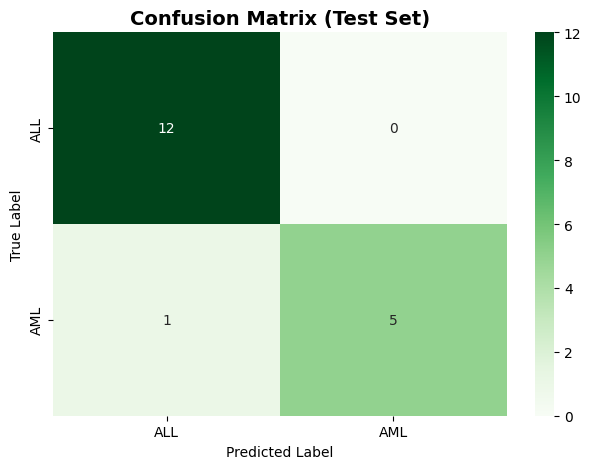


Total Runtime: 43.41 seconds


In [ ]:

# Main Execution


if __name__ == "__main__":
    
    print("Leukemia Classification (ALL vs AML)")
    
    
    start_time = time.time()

    X, y = load_data('leukemia_small.csv')
    X_selected, _ = select_features_robust(X, y, n_features=n_features)
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data_with_validation(X_selected, y)

    results = train_qsvm(X_train, y_train, X_val, y_val, X_test, y_test)

    
    print("FINAL RESULTS")
    
    print(f"Train Accuracy: {results['train_acc']:.2%}")
    print(f"Validation Accuracy: {results['val_acc']:.2%}")
    print(f"Test Accuracy: {results['test_acc']:.2%}")
    print(f"Regularization (C): {results['C']}")

    
    print("CLASSIFICATION REPORT (Test Set)")
    
    _, _, y_test_pred = results['predictions']
    print(classification_report(y_test, y_test_pred, target_names=['ALL', 'AML'], digits=4))

    plot_confusion_matrix(y_test, y_test_pred, title="Confusion Matrix (Test Set)")

    print(f"\nTotal Runtime: {time.time() - start_time:.2f} seconds")


In [25]:

n_qubits = 8
n_features = 15
dev = qml.device('default.qubit', wires=n_qubits)


Leukemia Classification (ALL vs AML)
Dataset shape: X=(72, 3571), y=(72,)
Class distribution: ALL=47, AML=25
FEATURE SELECTION (Cross-validated)
Selected top 15 features (stable across folds).
DATA SPLIT SUMMARY

 Train: 43 samples

 Validation: 11 samples

 Test: 18 samples
TRAINING QSVM


Test kernel: 100%|██████████| 774/774 [00:11<00:00, 69.23it/s]



Best C: 0.05, Validation Accuracy: 1.0000
FINAL RESULTS 
Train Accuracy: 93.02%
Validation Accuracy: 100.00%
Test Accuracy: 94.44%
Regularization (C): 0.05
CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

         ALL     0.9231    1.0000    0.9600        12
         AML     1.0000    0.8333    0.9091         6

    accuracy                         0.9444        18
   macro avg     0.9615    0.9167    0.9345        18
weighted avg     0.9487    0.9444    0.9430        18



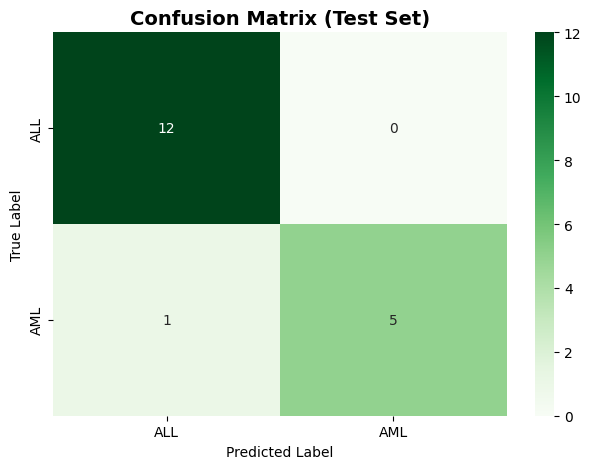


Total Runtime: 42.11 seconds


In [ ]:
# Main Execution


if __name__ == "__main__":
    
    print("Leukemia Classification (ALL vs AML)")
    
    
    start_time = time.time()

    X, y = load_data('leukemia_small.csv')
    X_selected, _ = select_features_robust(X, y, n_features=n_features)
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data_with_validation(X_selected, y)

    results = train_qsvm(X_train, y_train, X_val, y_val, X_test, y_test)

    
    print("FINAL RESULTS ")
    
    print(f"Train Accuracy: {results['train_acc']:.2%}")
    print(f"Validation Accuracy: {results['val_acc']:.2%}")
    print(f"Test Accuracy: {results['test_acc']:.2%}")
    print(f"Regularization (C): {results['C']}")

    
    print("CLASSIFICATION REPORT (Test Set)")
    
    _, _, y_test_pred = results['predictions']
    print(classification_report(y_test, y_test_pred, target_names=['ALL', 'AML'], digits=4))

    plot_confusion_matrix(y_test, y_test_pred, title="Confusion Matrix (Test Set)")

    print(f"\nTotal Runtime: {time.time() - start_time:.2f} seconds")


Leukemia Classification (ALL vs AML)
Dataset shape: X=(72, 3571), y=(72,)
Class distribution: ALL=47, AML=25
FEATURE SELECTION (Cross-validated)
Selected top 20 features (stable across folds).
DATA SPLIT SUMMARY

 Train: 43 samples

 Validation: 11 samples

 Test: 18 samples
TRAINING QSVM


Test kernel: 100%|██████████| 774/774 [00:09<00:00, 84.76it/s]



Best C: 0.05, Validation Accuracy: 1.0000
FINAL RESULTS
Train Accuracy: 95.35%
Validation Accuracy: 100.00%
Test Accuracy: 88.89%
Regularization (C): 0.05
CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

         ALL     0.8571    1.0000    0.9231        12
         AML     1.0000    0.6667    0.8000         6

    accuracy                         0.8889        18
   macro avg     0.9286    0.8333    0.8615        18
weighted avg     0.9048    0.8889    0.8821        18



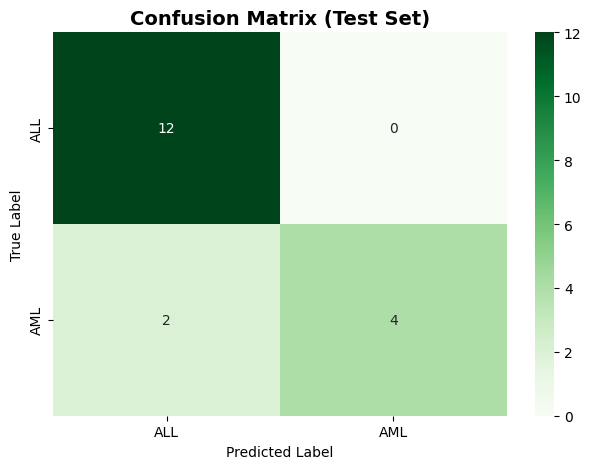


Total Runtime: 40.52 seconds


In [27]:

n_qubits = 8
n_features = 20
dev = qml.device('default.qubit', wires=n_qubits)



# Main Execution
if __name__ == "__main__":
    
    
    print("Leukemia Classification (ALL vs AML)")
    
    
    start_time = time.time()

    X, y = load_data('leukemia_small.csv')
    X_selected, _ = select_features_robust(X, y, n_features=n_features)
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data_with_validation(X_selected, y)

    results = train_qsvm(X_train, y_train, X_val, y_val, X_test, y_test)

    
    print("FINAL RESULTS")
    
    print(f"Train Accuracy: {results['train_acc']:.2%}")
    print(f"Validation Accuracy: {results['val_acc']:.2%}")
    print(f"Test Accuracy: {results['test_acc']:.2%}")
    print(f"Regularization (C): {results['C']}")

    
    print("CLASSIFICATION REPORT (Test Set)")
    
    _, _, y_test_pred = results['predictions']
    print(classification_report(y_test, y_test_pred, target_names=['ALL', 'AML'], digits=4))

    plot_confusion_matrix(y_test, y_test_pred, title="Confusion Matrix (Test Set)")

    print(f"\nTotal Runtime: {time.time() - start_time:.2f} seconds")


## final model selecetion

### top 15 features 
### resulting in Train Accuracy: 93.02%
### Validation Accuracy: 100.00%
### Test Accuracy: 94.44%